# Mini-Challenge: Intel Image Classification
**Deep Learning (DEL) – FS26**  
Autor: Damian Szedalik

### Aufgabe: 

Bildklassifikation auf dem [Intel Image Classification Dataset](https://www.kaggle.com/datasets/puneet6060/intel-image-classification/data) mit einem CNN in PyTorch.

## 0. Setup & Imports

Alle externen Bibliotheken werden einmalig importiert. Der W&B API-Key wird aus der `.env`-Datei geladen (`WANDB_API_KEY=...`). `wandb.login()` muss einmalig pro Session aufgerufen werden.

In [2]:
import os
import random
from pathlib import Path

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch import Tensor
from torch.utils.data import DataLoader, Subset, SubsetRandomSampler
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import wandb
from dotenv import load_dotenv

# Reproduzierbarkeit
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.mps.manual_seed(SEED)

load_dotenv()  # WANDB_API_KEY aus .env lesen

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

wandb.login()

Using device: mps


wandb: Currently logged in as: damiansze (damiansze-fachhochschule-nordwestschweiz-fhnw) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

## 1. Datenexploration

6 Klassen: buildings, forest, glacier, mountain, sea, street.  
~14 034 Train- / 3 000 Test-Bilder, originale Auflösung: 150×150 px.  
Ziel: Klassenverteilung prüfen (Balanciertheit) und geeignetes Preprocessing ableiten.

In [3]:
data_root = Path("./data/Intel_Image_Classification")

train_root = data_root/"seg_train"/"seg_train"
test_root  = data_root/"seg_test"/"seg_test"
pred_root  = data_root/"seg_pred"/"seg_pred"

classes = sorted([d.name for d in train_root.iterdir() if d.is_dir()])

# Bilder pro Klasse/Split
train_counts = {cls: len(list((train_root / cls).glob("*.jpg"))) for cls in classes}
test_counts  = {cls: len(list((test_root  / cls).glob("*.jpg"))) for cls in classes}
pred_count   = len(list(pred_root.glob("*.jpg")))

for i in classes:
    print(f"{i}: {train_counts[i]} (Train), {test_counts[i]} (Test)")
print(f"Pred (unlabeled): {pred_count} Bilder")
print(f"Gesamt:           {sum(train_counts.values()) + sum(test_counts.values()) + pred_count} Bilder")

buildings: 2191 (Train), 437 (Test)
forest: 2271 (Train), 474 (Test)
glacier: 2404 (Train), 553 (Test)
mountain: 2512 (Train), 525 (Test)
sea: 2274 (Train), 510 (Test)
street: 2382 (Train), 501 (Test)
Pred (unlabeled): 7301 Bilder
Gesamt:           24335 Bilder


In [4]:
# Get train and test images separately
train_imgs = list(train_root.rglob("*.jpg"))
test_imgs = list(test_root.rglob("*.jpg"))

for split_name, imgs in [("Train", train_imgs), ("Test", test_imgs)]:
    # Get resolutions
    resolutions = (Image.open(p).size for p in imgs)
    widths, heights = zip(*resolutions)

    # Get and print resolution statistics
    print(f"Auflösungsstatistik für {len(imgs)} {split_name}-Bilder:")
    print(f"  Breite – min, max: {min(widths)}, {max(widths)}")
    print(f"  Höhe   – min, max: {min(heights)}, {max(heights)}\n")

Auflösungsstatistik für 14034 Train-Bilder:
  Breite – min, max: 150, 150
  Höhe   – min, max: 76, 150

Auflösungsstatistik für 3000 Test-Bilder:
  Breite – min, max: 150, 150
  Höhe   – min, max: 72, 150



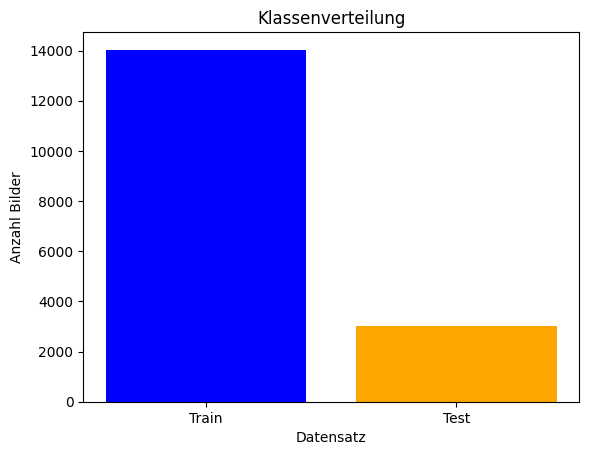

In [5]:
plt.bar(['Train', 'Test'], [len(train_imgs), len(test_imgs)], color=['blue', 'orange'])
plt.ylabel('Anzahl Bilder')
plt.xlabel('Datensatz')
plt.title('Klassenverteilung')
plt.show()

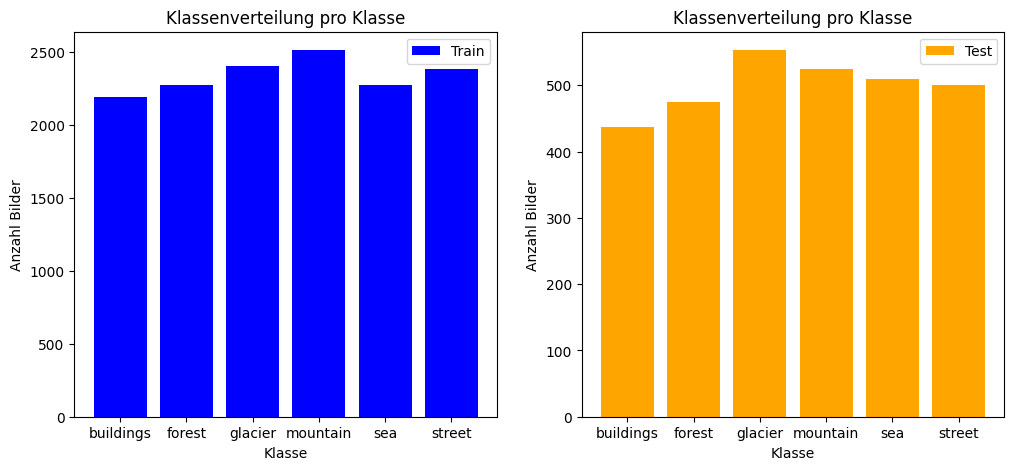

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].bar(classes, train_counts.values(), label='Train', color='blue')
axes[1].bar(classes, test_counts.values(), label='Test', color='orange')
axes[0].set_ylabel('Anzahl Bilder')
axes[0].set_xlabel('Klasse')
axes[1].set_ylabel('Anzahl Bilder')
axes[1].set_xlabel('Klasse')
axes[0].set_title('Klassenverteilung pro Klasse')
axes[1].set_title('Klassenverteilung pro Klasse')
axes[0].legend()
axes[1].legend()
plt.show()

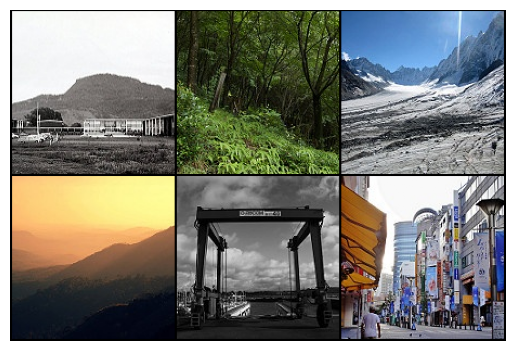

In [7]:
img_examples = ImageFolder(
    root=train_root,
    transform=transforms.ToTensor()
)
imgs = [img_examples[img_examples.targets.index(i)][0] for i in range(len(classes))]

grid = torchvision.utils.make_grid(imgs, nrow=3)

plt.imshow(grid.permute(1,2,0))
plt.axis("off")
plt.show()

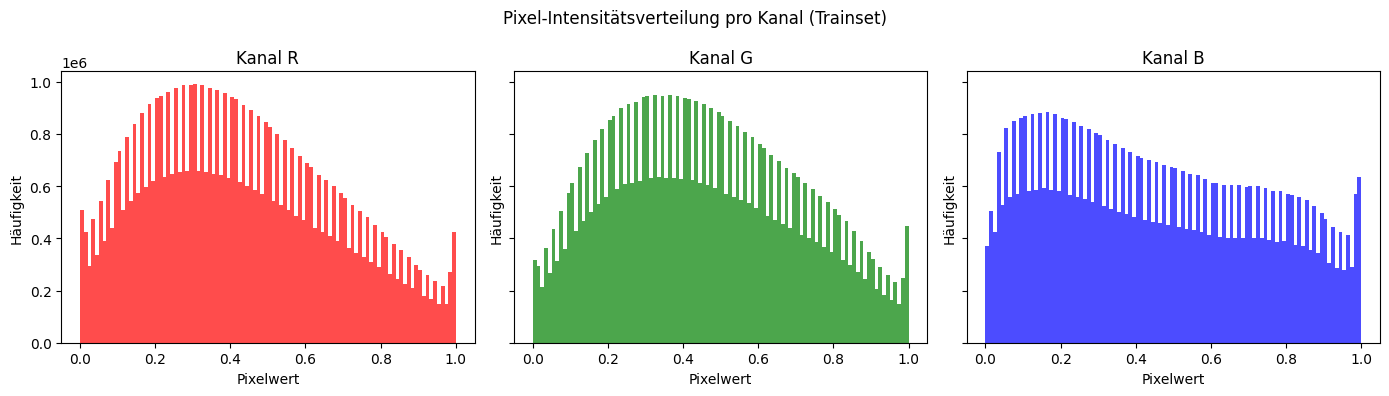

In [8]:
transform_hist = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])
ds_hist = ImageFolder(root=train_root, transform=transform_hist)
loader_hist = DataLoader(ds_hist, batch_size=256, shuffle=False, num_workers=2)

pixels = [[], [], []]
for imgs, _ in loader_hist:
    for c in range(3):
        pixels[c].append(imgs[:, c].flatten())

pixels = [torch.cat(p).numpy() for p in pixels]

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
colors = ['red', 'green', 'blue']
labels = ['R', 'G', 'B']
for c in range(3):
    axes[c].hist(pixels[c], bins=100, color=colors[c], alpha=0.7)
    axes[c].set_title(f'Kanal {labels[c]}')
    axes[c].set_xlabel('Pixelwert')
    axes[c].set_ylabel('Häufigkeit')
plt.suptitle('Pixel-Intensitätsverteilung pro Kanal (Trainset)')
plt.tight_layout()
plt.show()

### Fazit Datenexploration
Das Dataset ist mit 2191–2512 Bildern pro Klasse nahezu balanciert, somit kein Class-Imbalance-Problem. Der vom Dataset bereits gegebene Train-Test-Split ist passend mit ca. 80/20 Split.

Die Bildauflösungen variieren, die kleinste Höhe im Trainset beträgt 76 px. Um einheitliche Eingabedimensionen zu gewährleisten, werden alle Bilder auf 64×64 px resized (die nächste Power-of-2 unterhalb des Minimums, was gleichzeitig den Speicher- und Rechenaufwand reduziert).

Die Pixel-Intensitätsverteilungen unterscheiden sich kanalweise. R und G sind linkszentriert (~0.3–0.4), B flacher und rechtsverschoben. Da die Kanäle weder gleich verteilt noch zentriert sind, wird pro Kanal separat normalisiert (berechnete Mean/Std auf dem Trainset), sodass alle Kanäle mit ähnlicher Skalierung ins Modell rein gehen.

## 2. Preprocessing & DataLoader

Alle Bilder werden auf 64×64 px skaliert und als Float-Tensor normiert (ToTensor → [0, 1]). 

In [9]:
def compute_dataset_stats(dataset: ImageFolder) -> tuple[list[float], list[float]]:
    loader = DataLoader(dataset, batch_size=64, shuffle=False, num_workers=2)
    channel_sum    = torch.zeros(3)
    channel_sum_sq = torch.zeros(3)
    n_pixels = 0

    for imgs, _ in loader:
        channel_sum    += imgs.sum(dim=[0, 2, 3])
        channel_sum_sq += (imgs ** 2).sum(dim=[0, 2, 3])
        n_pixels       += imgs.size(0) * imgs.size(2) * imgs.size(3)

    mean = channel_sum / n_pixels
    std  = (channel_sum_sq / n_pixels - mean ** 2).sqrt()
    return mean.tolist(), std.tolist()

In [10]:
TARGET_SIZE = 64

# Rohes Transform für Statistik-Berechnung (keine Normalisierung)
transform_raw = transforms.Compose([
    transforms.Resize((TARGET_SIZE, TARGET_SIZE)),
    transforms.ToTensor(),
    # transforms.Normalize(mean=[0, 0, 0], std=[1, 1, 1])
])
train_ds_raw = ImageFolder(root=train_root, transform=transform_raw)

# Pro Kanal Mean und Std auf Trainset berechnen
mean, std = compute_dataset_stats(train_ds_raw)
print(f"Mean: {mean}")
print(f"Std:  {std}")

# Finales Transform mit Normalisierung
transform = transforms.Compose([
    transforms.Resize((TARGET_SIZE, TARGET_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

# Finale Datasets + DataLoader mit normalisierten Daten
train_ds = ImageFolder(root=train_root, transform=transform)
test_ds  = ImageFolder(root=test_root,  transform=transform)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=2)


imgs, labels = next(iter(train_loader))
print(f"Batch shape: {imgs.shape}")
print(f"Klassen: {train_ds.classes}")

Mean: [0.43018341064453125, 0.4574870467185974, 0.45385730266571045]
Std:  [0.24802614748477936, 0.24667836725711823, 0.28059622645378113]
Batch shape: torch.Size([32, 3, 64, 64])
Klassen: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


## 2b. Train / Validierungs-Split

`seg_test` dient ausschliesslich der **finalen Evaluation** und bleibt während der gesamten Modellentwicklung unberührt. Für Training und Hyperparameter-Tuning wird `seg_train` im Verhältnis 80/20 aufgeteilt.

Die Aufteilung erfolgt **stratifiziert** (`stratify=labels`), damit beide Teilmengen dieselbe Klassenverteilung wie das Originalset aufweisen. Ohne Stratifizierung könnten einzelne Klassen im Validierungsset über- oder unterrepräsentiert sein, was die Metriken verzerren würde.

Mit ~11 200 Trainings- und ~2 800 Validierungsbildern ist das Validierungsset gross genug für stabile Metriken, ohne zu viele Trainingsbeispiele zu opfern.

In [11]:
def get_split_dataloaders(
    train_ds,
    batch_size: int,
    val_size: float = 0.2,
    seed: int = 42,
    num_workers: int = 2
):
    """Stratifizierter 80/20-Split von seg_train in Train- und Val-DataLoaders."""
    all_indices = list(range(len(train_ds)))
    train_idx, val_idx = train_test_split(
        all_indices,
        test_size=val_size,
        random_state=seed,
        stratify=train_ds.targets
    )
    train_subset = Subset(train_ds, train_idx)
    val_subset   = Subset(train_ds, val_idx)
    train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True,  num_workers=num_workers)
    val_loader   = DataLoader(val_subset,   batch_size=batch_size, shuffle=False, num_workers=num_workers)
    return train_loader, val_loader, train_idx, val_idx

In [11]:
train_loader, val_loader, train_idx, val_idx = get_split_dataloaders(
    train_ds, batch_size=32, seed=SEED
)

print(f"Train-Subset:      {len(train_idx):>6} Bilder  ({len(train_idx)/len(train_ds)*100:.1f}%)")
print(f"Validierungs-Set:  {len(val_idx):>6} Bilder  ({len(val_idx)/len(train_ds)*100:.1f}%)")
print(f"Test-Set (final):  {len(test_ds):>6} Bilder")

Train-Subset:       11227 Bilder  (80.0%)
Validierungs-Set:    2807 Bilder  (20.0%)
Test-Set (final):    3000 Bilder


## 3. Metriken

Kostenfunktion: `nn.CrossEntropyLoss`.  
Metriken: **Accuracy** und **Macro-F1** via `sklearn.metrics`.  
Macro-F1 mittelt den F1-Score gleichgewichtet über alle 6 Klassen. Sinnvoll, da das Dataset nahezu balanciert ist (2191–2512 Bilder/Klasse) und Schwächen bei einzelnen Klassen sichtbar gemacht werden sollen.

Zusätzlich werden auch je nach Situation folgende Plots für Evaluationen genutzt:
- **Loss- & Accuracy-Kurven** (Train vs. Val über Epochen) — zeigt Lernfortschritt und Overfitting
- **Confusion Matrix** (Heatmap) — zeigt systematische Verwechslungen zwischen Klassen
- **Per-Klassen-F1** (Barplot) — zeigt welche Klassen gut bzw. schlecht klassifiziert werden

Alle Metriken und Plots werden via **Weights & Biases (W&B)** geloggt.

## 4. Modell-Architektur



### Architektur:
| Block              | Layer                                                       | Parameter  |
| ------------------ | ----------------------------------------------------------- | ---------- |
| Feature Extraction | Conv2d(3 -> 32, kernel=3, padding=1) + ReLU + MaxPool(2×2)   | 32 Filter  |
| Feature Extraction | Conv2d(32 -> 64, kernel=3, padding=1) + ReLU + MaxPool(2×2)  | 64 Filter  |
| Feature Extraction | Conv2d(64 -> 128, kernel=3, padding=1) + ReLU + MaxPool(2×2) | 128 Filter |
| Classification     | Flatten -> Linear(8192 -> 256) + ReLU                         | 256 Units  |
| Classification     | Linear(256 -> 6)                                             | 6 Ausgaben |

### Training:
- Optimizer: SGD ohne Momentum
- Loss: CrossEntropyLoss
- Keine Regularisierung, kein BatchNorm, kein Dropout
- Lernrate und Batchsize werden manuell getuned

In [12]:
class BaseCNN(nn.Module):
    def __init__(self, num_classes: int, conv_channels: list[int], fc_units: int, img_size: int = 64):
        super(BaseCNN, self).__init__()
        flatten_size = conv_channels[-1] * (img_size // 2**len(conv_channels))**2
        self.layers = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=conv_channels[0], kernel_size=3, padding=1),
            nn.ReLU(),
            nn. MaxPool2d(kernel_size=2),
            nn.Conv2d(in_channels=conv_channels[0], out_channels=conv_channels[1], kernel_size=3, padding=1),
            nn.ReLU(),
            nn. MaxPool2d(kernel_size=2),
            nn.Conv2d(in_channels=conv_channels[1], out_channels=conv_channels[2], kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Flatten(),
            nn.Linear(flatten_size, fc_units),
            nn.ReLU(),
            nn.Linear(fc_units, num_classes)
        )
    
    def forward(self, x: Tensor) -> Tensor:
        z = self.layers(x)
        return z


def build_model(num_classes, conv_channels, fc_units, device, img_size=64) -> BaseCNN:
    return BaseCNN(num_classes, conv_channels, fc_units, img_size).to(device)

## 5. Trainings- und Evaluationsinfrastruktur

Die folgenden Funktionen bilden den vollständigen Trainingszyklus:
- `train_one_epoch`: ein Trainingsschritt über alle Batches mit Backpropagation
- `evaluate`: Validierung ohne Gradientenberechnung
- `train`: orchestriert den Epoch-Loop, loggt Metriken an W&B und gibt die History zurück
- `_plot_confusion_matrix`: Hilfsfunktion zur Visualisierung einer Confusion Matrix in wandb

In [13]:
def train_one_epoch(model, loader, optimizer, criterion, device) -> tuple[float, float]:
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * inputs.size(0)
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / total
    avg_acc = correct / total

    return avg_loss, avg_acc

In [ ]:
def evaluate(model, loader, criterion, device) -> tuple[float, float, list, list]:
    model.eval()
    total_loss = 0.0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * inputs.size(0)
            total += inputs.size(0)
            all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / total
    avg_acc  = accuracy_score(all_labels, all_preds)

    return avg_loss, avg_acc, all_preds, all_labels

In [15]:
CLASS_NAMES = ["buildings", "forest", "glacier", "mountain", "sea", "street"]

def _plot_confusion_matrix(cm: np.ndarray, class_names: list, normalize: bool = False, subtitle: str | None = None) -> plt.Figure:
    if normalize:
        cm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(cm, interpolation="nearest", cmap="Blues", vmin=0, vmax=(1.0 if normalize else None))
    plt.colorbar(im, ax=ax)
    ax.set_xticks(range(len(class_names)))
    ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticklabels(class_names)

    thresh = 0.5 if normalize else cm.max() / 2
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            val = cm[i, j]
            ax.text(
                j, i,
                f"{val:.2f}" if normalize else str(int(val)),
                ha="center", va="center",
                color="white" if val > thresh else "black"
            )

    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

    title = "Confusion Matrix" + (" (normalized)" if normalize else "")
    if subtitle:
        title += f"\n{subtitle}"
    ax.set_title(title)

    plt.tight_layout()
    return fig

In [16]:
def train(config: dict, train_loader, val_loader, device) -> dict:
    model = build_model(config["num_classes"], config["conv_channels"], config["fc_units"], device)
    optimizer = torch.optim.SGD(model.parameters(), lr=config["lr"], momentum=0)
    criterion = nn.CrossEntropyLoss()

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "val_f1": []}

    wandb.init(project="del-intel-clf", name=f"{config['run_name']}_lr{config['lr']}_bs{config['batch_size']}",
               group=config.get("group"), config=config)

    try:
        for epoch in range(config["num_epochs"]):
            train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
            val_loss, val_acc, preds, labels = evaluate(model, val_loader, criterion, device)
            val_f1 = f1_score(labels, preds, average="macro")

            wandb.log({"epoch": epoch,
                       "train/loss": train_loss, "train/acc": train_acc,
                       "val/loss": val_loss, "val/acc": val_acc, "val/f1_macro": val_f1})

            history["train_loss"].append(train_loss)
            history["val_loss"].append(val_loss)
            history["train_acc"].append(train_acc)
            history["val_acc"].append(val_acc)
            history["val_f1"].append(val_f1)

        if config.get("final_eval"):
            _, _, preds, labels = evaluate(model, val_loader, criterion, device)
            cm = confusion_matrix(labels, preds)
            f1_per_class = f1_score(labels, preds, average=None)

            fig_norm = _plot_confusion_matrix(cm, CLASS_NAMES, normalize=True, subtitle=wandb.run.name)

            wandb.log({
                "confusion_matrix_norm": wandb.Image(fig_norm),
                "f1_per_class": wandb.plot.bar(
                    wandb.Table(data=[[c, float(f)] for c, f in zip(CLASS_NAMES, f1_per_class)],
                                columns=["Klasse", "F1"]),
                    "Klasse", "F1", title="Per-Class F1")
            })
            plt.close(fig_norm)

        print(f"W&B Run: {wandb.run.url}")
        history["run_url"] = wandb.run.url
    finally:
        wandb.finish()

    return history

## 6. Overfitting-Test

Das Modell wird auf einem einzigen Batch overfittet.  
**Erwartung:** Loss → 0, Accuracy = 100 % 
Bestätigt korrekte Forward- und Backward-Propagation.

Epoch  0: Loss = 1.7913
Epoch  1: Loss = 1.7571
Epoch  2: Loss = 1.7300
Epoch  3: Loss = 1.7032
Epoch  4: Loss = 1.6745
Epoch  5: Loss = 1.6426
Epoch  6: Loss = 1.6088
Epoch  7: Loss = 1.5724
Epoch  8: Loss = 1.5322
Epoch  9: Loss = 1.4857
Epoch 10: Loss = 1.4314
Epoch 11: Loss = 1.3666
Epoch 12: Loss = 1.2892
Epoch 13: Loss = 1.1982
Epoch 14: Loss = 1.1153
Epoch 15: Loss = 1.3011
Epoch 16: Loss = 2.0612
Epoch 17: Loss = 1.4149
Epoch 18: Loss = 1.1742
Epoch 19: Loss = 0.9891
Epoch 20: Loss = 0.8447
Epoch 21: Loss = 0.7491
Epoch 22: Loss = 0.9642
Epoch 23: Loss = 2.3348
Epoch 24: Loss = 1.6779
Epoch 25: Loss = 1.4028
Epoch 26: Loss = 1.0736
Epoch 27: Loss = 0.8418
Epoch 28: Loss = 0.6958
Epoch 29: Loss = 0.5862
Epoch 30: Loss = 0.4922
Epoch 31: Loss = 0.4110
Epoch 32: Loss = 0.3429
Epoch 33: Loss = 0.2857
Epoch 34: Loss = 0.2754
Epoch 35: Loss = 0.7010
Epoch 36: Loss = 1.5442
Epoch 37: Loss = 1.6688
Epoch 38: Loss = 1.1483
Epoch 39: Loss = 0.8101
Epoch 40: Loss = 0.6445
Epoch 41: Loss =

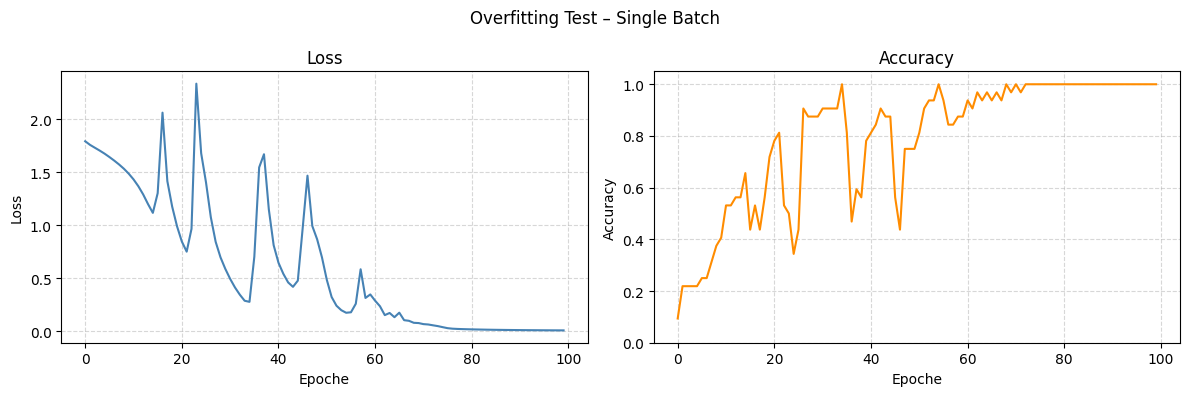

In [16]:
model = build_model(num_classes=6, conv_channels=[32, 64, 128], fc_units=256, device=device, img_size=64)
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)
criterion = nn.CrossEntropyLoss()

inputs, labels = next(iter(train_loader))
inputs, labels = inputs.to(device), labels.to(device)

losses = []
accuracies = []

for epoch in range(100):
    optimizer.zero_grad()
    outputs = model(inputs)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    preds = outputs.argmax(dim=1).cpu().numpy()
    accuracies.append(accuracy_score(labels.cpu().numpy(), preds))
    print(f"Epoch {epoch:2d}: Loss = {loss.item():.4f}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(losses, color="steelblue")
ax[0].set_title("Loss")
ax[0].set_xlabel("Epoche")
ax[0].set_ylabel("Loss")
ax[0].grid(True, linestyle="--", alpha=0.5)

ax[1].plot(accuracies, color="darkorange")
ax[1].set_title("Accuracy")
ax[1].set_xlabel("Epoche")
ax[1].set_ylabel("Accuracy")
ax[1].set_ylim(0, 1.05)
ax[1].grid(True, linestyle="--", alpha=0.5)

fig.suptitle("Overfitting Test – Single Batch")
plt.tight_layout()
plt.show()

**Interpretation Overfitting-Modell**
Der Overfitting-Test ist erfolgreich. Der Loss fällt über die Epochen (fast) auf 0, während die Accuracy auf 100 % steigt und dort stabil bleibt. Damit zeigt das Modell, dass es einen einzelnen Batch vollständig auswendig lernen kann.

Ursachen der Spikes:
- Hohe Lernrate (`lr=0.05`): Der Optimizer macht zu grosse Schritte und überschiesst Minima.
- Loss-Landscape: Scharfe Täler und Sattelpunkte im nicht-konvexen CNN-Landscape führen zu kurzzeitigen Anstiegen.
- Keine Batchnorm: Ohne Normalisierung der Aktivierungen zwischen den Layern können interne Repräsentationen stark schwanken (Internal Covariate Shift). Das destabilisiert den Gradientenfluss und begünstigt Spikes.
- Kein Momentum: Plain SGD reagiert ungefiltert auf jeden Gradienten. Ohne die glättende Wirkung von Momentum entstehen stärkere Schwankungen und Spikes.

## 7. Baseline-Modell-Training

Einmaliges Training des Basismodells auf allen Trainingsdaten:  
SGD ohne Momentum, keine Regularisierung, kein BatchNorm.  
Parameter: `lr=1e-2`, `batch_size=32`, `num_epochs=20`.

Dieses Ergebnis dient als Referenzpunkt für das anschliessende Hyperparameter-Tuning.

In [20]:
baseline_config = {
    "lr": 1e-2,
    "batch_size": 32,
    "num_epochs": 100,
    "num_classes": 6,
    "conv_channels": [32, 64, 128],
    "fc_units": 256,
    "run_name": "base",
    "group": "etappe1",
    "final_eval": True
}

baseline_history = train(baseline_config, train_loader, val_loader, device)

W&B Run: https://wandb.ai/damiansze-fachhochschule-nordwestschweiz-fhnw/del-intel-clf/runs/y694hy2c


epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▄▄▄▄▄▄▄▄▄▅▅▅▅▆▆▆▇▇▇▇▇▇▇███
train/acc,▁▃▄▅▆▆▇▇▇▇██████████████████████████████
train/loss,█▆▅▅▄▄▄▄▃▃▃▃▂▂▂▁▁▁▁▁▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/acc,▃▃▃▁▄▆▆▆▇▆▇▇▇▇█▇██████▆█▇▇█▇█▇█▇▇█▇▇▇▇▇▇
val/f1_macro,▁▅▅▆▅▇▇█▇▇██████████████████████████████
val/loss,▆▆▂▃▂▁▁▁▂▁▂▂▂▄▄▅▅▅▆▆▆▃▄▆▆▆▆▆▇▇▇▇▆▇▇▇█▇▇▇
epoch,99
train/acc,0.99911
train/loss,0.00466
val/acc,0.80157
val/f1_macro,0.80291


<iframe src="https://wandb.ai/damiansze-fachhochschule-nordwestschweiz-fhnw/del-intel-clf/reports/Baseline-Model--VmlldzoxNjM5NTIwOA" style="border:none;height:1024px;width:100%">

**Interpretation:**
Das Baseline-Modell erreicht eine solide Validierungsleistung von rund 80 % Accuracy. Die Trainingskurven zeigen, dass das Modell die Trainingsdaten sehr gut lernt. Der Train-Loss sinkt stetig, während die Train-Accuracy fast 98 % erreicht. Auf dem Validierungsset verbessert sich die Leistung am Anfang deutlich, stagniert aber ab etwa Epoche 10–12. Gleichzeitig steigt der Val-Loss wieder an und schwankt stark. Das deutet auf Overfitting hin. Die Confusion Matrix zeigt ausserdem, dass vor allem ähnliche Landschaftsklassen wie glacier, mountain und sea verwechselt werden. Das Baseline-Modell ist damit eine gute Ausgangsbasis, bietet aber noch klares Optimierungspotenzial.

## 8. Lernraten-Tuning

Der Einfluss der Lernrate wird mit manuellem Grid-Search untersucht.  
Alle anderen Parameter fix: `batch_size=32`, SGD ohne Momentum, `num_epochs=30`.

**Erwartung:**  
- Zu kleine LR: langsame Konvergenz  
- Zu grosse LR: instabiler Loss, Divergenz  
- Optimale LR: schnelle und stabile Konvergenz

Die Lernraten wurden in mehreren Grössenordnungen im Bereich von 0.00001 bis 0.1 gewählt, mit einer ungefähr logarithmischen Abstufung. Diese Spannweite deckt kleine und sehr grosse Lernraten ab. Kleine Lernraten führen erfahrungsgemäss zu langsamer, aber stabiler Optimierung, während grosse Lernraten schnellere Fortschritte ermöglichen, aber das Risiko von Instabilität oder schlechter Generalisierung erhöhen. Durch die logarithmische Abstufung kann der Übergang zwischen diesen Bereichen untersucht werden.

In [ ]:
lr_values = [1e-5, 3e-5, 1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 5e-2, 1e-1]
all_histories_lr = {}

for lr in lr_values:
    config = {
        "lr": lr,
        "batch_size": 32,
        "num_epochs": 100,
        "num_classes": 6,
        "conv_channels": [32, 64, 128],
        "fc_units": 256,
        "run_name": "lr-tune",
        "group": "etappe1",
        "final_eval": False
    }
    history = train(config, train_loader, val_loader, device)
    all_histories_lr[f"lr={lr}"] = history

W&B Run: https://wandb.ai/damiansze-fachhochschule-nordwestschweiz-fhnw/del-intel-clf/runs/0buj0ndd


epoch,▁▁▁▁▁▂▂▂▂▂▂▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇███
train/acc,▁▄▄▄▅▅▅▅▆▆▆▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇█████████████
train/loss,██▇▇▆▆▅▅▅▅▅▅▄▄▄▄▄▄▄▄▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
val/acc,▃▃▄▅▄▄▆▅▆▆▇▆▇▇▇█▇█████████▁█████▆▇██████
val/f1_macro,▁▃▄▅▅▆▆▆▆▇▆▇▇▇▇█▆██████████▅███▇████████
val/loss,█▆▅▄▄▃▃▃▃▂▂▃▁▁▁▃▂▁▁▁▁▂▂▁▁▂▂▂▂▂▂▃▃▃▃▄▄▄▄▄
epoch,99
train/acc,0.99706
train/loss,0.01879
val/acc,0.80549
val/f1_macro,0.80755


W&B Run: https://wandb.ai/damiansze-fachhochschule-nordwestschweiz-fhnw/del-intel-clf/runs/674qbhxw


epoch,▁▁▂▂▂▂▂▂▂▂▃▃▃▃▃▄▄▄▅▅▅▅▅▅▅▅▆▆▆▆▆▆▆▆▇▇▇███
train/acc,▁▃▄▄▅▅▅▅▆▆▇▇▇▇▇█████████████████████████
train/loss,█▇▆▆▆▅▅▅▄▄▃▃▃▃▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/acc,▁▄▅▅▅▇▇▇█▇█▇▇▇████▇██▆███████▇██████████
val/f1_macro,▁▅▅▇▇▇███▇██▇█████▇████████████▇████████
val/loss,▄▂▂▂▂▁▁▁▁▁▂▂▂▂▃▃▄▄█▃▄▄▄▄▃▄▄▄▄▄▄▄▄▅▄▅▅▄▄▄
epoch,99
train/acc,0.99902
train/loss,0.00411
val/acc,0.81902
val/f1_macro,0.82003


W&B Run: https://wandb.ai/damiansze-fachhochschule-nordwestschweiz-fhnw/del-intel-clf/runs/3hjdpbph


epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇▇███
train/acc,▁▃▅▇▇███████████████████████████████████
train/loss,█▆▆▅▅▃▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/acc,▁▃▂▇▇█▇█▇▆██████████████████████████████
val/f1_macro,▁▇▆▇▇▇█▆█▇▇█▇███████████████████████████
val/loss,█▂▁▁▂▄▄▅▇▅▆▇▆▇▇▇▇▇▇▆▇▇▇▇▇▇█▇▇▇▇▇▇█▇█████
epoch,99
train/acc,0.99938
train/loss,0.00148
val/acc,0.82009
val/f1_macro,0.8215


W&B Run: https://wandb.ai/damiansze-fachhochschule-nordwestschweiz-fhnw/del-intel-clf/runs/9sb8tct7


epoch,▁▁▁▁▁▁▂▂▂▂▂▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇█████
train/acc,▁▂▃▅▆███████████████████████████████████
train/loss,█▇▆▃▃▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/acc,▃▅▇▁▂▄▆▇█▇█▇▇██▇▇▆██▇▇▇▇▇▇▇▇▇▇▇█▇▇▇▇▇▇█▇
val/f1_macro,▁▄▇▇████████████████████████████████████
val/loss,▄▃▁▁▄▅▅▆▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇██████████
epoch,99
train/acc,0.99938
train/loss,0.00087
val/acc,0.80086
val/f1_macro,0.8019


W&B Run: https://wandb.ai/damiansze-fachhochschule-nordwestschweiz-fhnw/del-intel-clf/runs/7jlg1eff


epoch,▁▁▁▁▂▂▂▂▂▂▂▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇█
train/acc,▁▆▇▇████████████████████████████████████
train/loss,█▆▅▄▄▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/acc,▁▆▆▆▇▇▇▆▇▇██████████████████████████████
val/f1_macro,▁▅▆▆▆▆▅▇▇▆▇▇████████████████████████████
val/loss,▃▁▁▂▂▃▅▄▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇██████████
epoch,99
train/acc,0.99947
train/loss,0.00069
val/acc,0.81154
val/f1_macro,0.81209


<iframe src="https://wandb.ai/damiansze-fachhochschule-nordwestschweiz-fhnw/del-intel-clf/reports/Lernraten-Tuning--VmlldzoxNjQwMDUxMg" style="border:none;height:1024px;width:100%">

**Beobachtungen verschiedener Lernraten**
0.00001 (türkis) & 0.00003 (orange): Der Train-Loss fällt praktisch nicht, entsprechend bleiben auch die Validation-Metriken sehr schlecht (f1 < 0.4; acc < 0.5). Diese Lernraten sind hierfür zu klein.
0.0001 (hell-grün): Zeigt zwar stetigen Fortschritt in Training und Validation, lernt aber deutlich zu langsam. Nach 100 Epochen ist das Modell noch nicht "fertig trainiert". Train- und Val-Loss fallen beide noch.
0.0003 (braun) & 0.001 (dunkel-pink): Beide zeigen einen sauberen und stabilen Lernverlauf. Auch diese Lernraten scheinen aber nach 100 Epochen noch nicht fertig trainiert zu sein.
0.003 (blau): Zeigt bis ca. Epoche 50-60 einen guten Verlauf, dann steigt Validation Loss wieder an (Overfittet). Bisher die beste Lernrate, wenn man bei ca. 50 Epochen early-stopped. Zudem erreicht diese Lernrate den tiefsten Validation Loss bei akzeptabler Anzahl Epochen.
0.01 (rot): Zeigt einen schnellen Fall vom Validation Loss aber beginnt nach Epoche 20 zu Overfitten.
0.03 (dunkel-grün) & 0.05 (violett) & 0.1 (hell-pink): Erreichen schnell einen tiefen Loss und hohe Validation Accuracy. Aber beginnen bereits nach 10 Epochen zu Overfitten, definitiv zu hoch.

Zusätzlich fällt auf, dass Validation Accuracy und Validation F1-Macro immer ziemlich genau gleich aussehen. Das passiert, wegen den sehr ausgeglichenen Klassen. Trotzdem werden beide Metriken weiterhin beibehalten.

Die vereinzelten Spikes im Validation Loss sind wahrscheinlich auf SGD ohne Momentum zurückzuführen. Da jeder Gradient ungefiltert übernommen wird, können einzelne schwierige Batches die Gewichte kurzzeitig destabilisieren und zu kurzen Ausreissern im Loss führen.

**Zusammenfassung:**
Sehr kleine Lernraten wie 0.00001, 0.00003 und teilweise auch 0.0001 führen zu langsamem oder fast keinem Lernen. Sehr grosse Lernraten wie 0.03 bis 0.1 ermöglichen zwar schnelle Fortschritte und erreichen teils hohe Accuracy und F1 Werte auf Train und Validation, führen aber klar zu Overfitting.

Der sinnvollste Bereich liegt im mittleren Bereich, insbesondere bei 0.001 oder 0.003. Wenn Rechenzeit kein Problem wäre, hätte ich mich für 0.001 entschieden, da dieser scheinbar noch im Validation Loss weiter sinken könnte und der Training Loss noch nicht auf 0 gesunken ist. Da ich aber einen akzeptablen Aufwand-Nutzen-Tradeoff suche, **entscheide ich mich für 0.003**, da dieser bei ca. 50 Epochen bereits einen ziemlich stabilen Validation Loss hat.

## 9. Batchsize-Tuning

Mit der gewählten optimalen Lernrate von 0.003 wird der Einfluss der Batchsize untersucht. Hier wird erneut mit 100 Epochen trainiert um das "volle Muster" zu sehen, jedoch werde ich hierbei auch wieder die Rechenzeit (bzw. Anzahl Epochen) in der Entscheidung für die beste Batchsize miteinbeziehen.

**Erwartung (Theorie):** 
- Kleine Batchsize (mehr Updates pro Epoche) -> stochastischere Gradienten, mögliche Regularisierungswirkung durch höheres Rauschen
- Grosse Batchsize (weniger Updates pro Epoche) -> stabilere Gradienten, Tendenz zu Sharp Minima und somit schlechterer Generalisierung

In [17]:
# batch_sizes = [16, 32, 64, 128]
batch_sizes = [64, 128]
all_histories_bs = {}

for bs in batch_sizes:
    config = {
        "lr": 0.003,
        "batch_size": bs,
        "num_epochs": 100,
        "num_classes": 6,
        "conv_channels": [32, 64, 128],
        "fc_units": 256,
        "run_name": "bs-tune",
        "group": "etappe1",
        "final_eval": False
    }
    train_loader_bs, val_loader_bs, _, _ = get_split_dataloaders(train_ds, batch_size=bs, seed=SEED)
    history = train(config, train_loader_bs, val_loader_bs, device)
    all_histories_bs[f"bs={bs}"] = history

W&B Run: https://wandb.ai/damiansze-fachhochschule-nordwestschweiz-fhnw/del-intel-clf/runs/5xw6g8mb


epoch,▁▁▂▂▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇████
train/acc,▁▄▅▅▅▆▆▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇██████████
train/loss,█▆▆▅▅▅▄▄▄▄▃▃▃▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁
val/acc,▁▄▄▅▅▅▆▆▆▆▇▆▇▇▇▇█▇▆▇███▇████████████████
val/f1_macro,▁▃▄▄▅▆▆▆▆▆▆▆▆▆▇▇▆▇▇▇▇▇████████████▇█████
val/loss,█▅▅▄▃▃▃▄▃▂▂▂▂▂▂▁▁▁▁▂▁▁▁▁▁▁▁▂▁▁▁▁▁▁▁▂▁▁▁▂
epoch,99
train/acc,0.91244
train/loss,0.2655
val/acc,0.79337
val/f1_macro,0.79676


W&B Run: https://wandb.ai/damiansze-fachhochschule-nordwestschweiz-fhnw/del-intel-clf/runs/3ogklmlz


epoch,▁▁▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▅▅▅▅▅▅▅▅▆▆▆▆▇▇▇▇███
train/acc,▁▄▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇████████████████
train/loss,█▆▅▅▅▄▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/acc,▁▄▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇█▇▇███████████████
val/f1_macro,▁▁▃▄▄▅▅▅▆▆▆▆▆▇▇▆▇▇▇▇▇▇▇▇▇▇▇▇███▇█▇██████
val/loss,██▆▅▅▄▄▃▃▃▂▂▂▂▂▂▂▂▂▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,99
train/acc,0.79603
train/loss,0.57046
val/acc,0.77057
val/f1_macro,0.77138


<iframe src="https://wandb.ai/damiansze-fachhochschule-nordwestschweiz-fhnw/del-intel-clf/reports/Batchsize-Tuning--VmlldzoxNjUxMTM5NQ" style="border:none;height:1024px;width:100%">

**Beobachtungen verschiedener Batchsizes:**
128 (pink): Lernt am langsamsten, hat nach 100 Epochen scheinbar noch nicht fertig gelernt.

64 (braun): Zeigt einen schnelleren Lernverlauf, macht nach ca. 80 Epochen keine Verbesserung mehr in der Validation Accuracy.

32 (beige): Fängt nach ca. 35 Epochen an zu Overfitten, Validation Loss fängt leicht an zu steigen.

16 (grau): Validation Loss sinkt am schnellsten, aber danach steigt es auch sehr schnell wieder an.

Zusätzlich verhalten sich Validation Accuracy und Validation F1-Macro erneut fast identisch, was wegen der relativ ausgeglichenen Klassenverteilung plausibel ist.

**Zusammenfassung:**
`bs=32` zeigt die beste Gesamtleistung und generalisiert am besten bei akzeptabler Anzahl Epochen (ca. 35 Epcohen). `bs=16` ist zu instabil, der Validation Loss steigt zu schnell wieder an. Sehr grosse Batches wie `bs=128` führen zu zu langsamem Lernen.

Für die weitere Arbeit ist daher `batch_size = 32` die beste Wahl, wenn ich wieder einen Aufwand-Effizienz-Tradoff miteinbeziehe.

## 10. Statistische Fehlerabschätzung (Cross-Validation)

Mittels 5-Fold Cross-Validation wird die Stabilität des Modells auf dem Trainingsdatensatz untersucht. Pro Fold wird das Modell neu initialisiert, auf 4 Folds trainiert und auf dem verbleibenden Fold evaluiert. Aus den Resultaten über alle 5 Folds werden Mittelwert ± Standardabweichung für Accuracy und Macro-F1 berechnet.

In [18]:
def run_cross_validation(dataset, config: dict, device, n_splits: int = 5) -> dict:
    """
    k-Fold CV auf vollem train_ds (seg_train, alle 14 034 Bilder).
    Ein W&B-Run für den gesamten CV-Lauf, Folds als namespaced Keys.
    """
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    indices = list(range(len(dataset)))
    fold_results = []
    criterion = nn.CrossEntropyLoss()

    wandb.init(
        project="del-intel-clf",
        name=f"cv_{n_splits}fold_lr{config['lr']}_bs{config['batch_size']}",
        group=config.get("group", "etappe1"),
        config={**config, "cv_n_splits": n_splits}
    )
    try:
        for fold, (train_idx, val_idx) in enumerate(skf.split(indices, dataset.targets)):
            print(f"\n--- Fold {fold+1}/{n_splits} ---")
            train_sampler = SubsetRandomSampler(train_idx)
            val_sampler   = SubsetRandomSampler(val_idx)
            fold_train_loader = DataLoader(dataset, batch_size=config["batch_size"],
                                           sampler=train_sampler, num_workers=2)
            fold_val_loader   = DataLoader(dataset, batch_size=config["batch_size"],
                                           sampler=val_sampler,   num_workers=2)

            model     = build_model(config["num_classes"], config["conv_channels"],
                                    config["fc_units"], device)
            optimizer = torch.optim.SGD(model.parameters(), lr=config["lr"], momentum=0)

            for epoch in range(config["num_epochs"]):
                train_loss, train_acc = train_one_epoch(model, fold_train_loader,
                                                         optimizer, criterion, device)
                val_loss, val_acc, preds, labels = evaluate(model, fold_val_loader,
                                                             criterion, device)
                val_f1 = f1_score(labels, preds, average="macro")
                wandb.log({
                    "fold": fold+1, "epoch": epoch,
                    f"fold{fold+1}/train_loss": train_loss,
                    f"fold{fold+1}/train_acc":  train_acc,
                    f"fold{fold+1}/val_loss":   val_loss,
                    f"fold{fold+1}/val_acc":    val_acc,
                    f"fold{fold+1}/val_f1":     val_f1,
                })
                if (epoch+1) % 5 == 0:
                    print(f"  Epoch {epoch+1:>2}/{config['num_epochs']}  "
                          f"val_acc={val_acc:.4f}  val_f1={val_f1:.4f}")

            fold_f1 = f1_score(preds, labels, average="macro")  # was: fold_preds, fold_labels
            fold_results.append({"fold": fold+1, "val_acc": val_acc, "val_f1": fold_f1})
            print(f"  Fold {fold+1} final: val_acc={val_acc:.4f}, val_f1={fold_f1:.4f}")

        accs = [r["val_acc"] for r in fold_results]
        f1s  = [r["val_f1"]  for r in fold_results]
        mean_acc, std_acc = float(np.mean(accs)), float(np.std(accs))
        mean_f1,  std_f1  = float(np.mean(f1s)),  float(np.std(f1s))

        # Ergebnis-Tabelle mit allen Fold-Metriken
        table = wandb.Table(
            columns=["Fold", "Val Accuracy", "Val F1 (macro)"],
            data=[[r["fold"], r["val_acc"], r["val_f1"]] for r in fold_results]
        )

        # Native W&B Balkendiagramme (interaktiv im Dashboard)
        acc_table = wandb.Table(
            columns=["Fold", "Val Accuracy"],
            data=[[f"Fold {r['fold']}", r["val_acc"]] for r in fold_results]
        )
        f1_table = wandb.Table(
            columns=["Fold", "Val F1 (macro)"],
            data=[[f"Fold {r['fold']}", r["val_f1"]] for r in fold_results]
        )
        scatter_table = wandb.Table(
            columns=["Fold", "Val Accuracy", "Val F1 (macro)"],
            data=[[f"Fold {r['fold']}", r["val_acc"], r["val_f1"]] for r in fold_results]
        )                                                                      

        wandb.log({
            "cv_results_table": table,
            "cv/mean_acc": mean_acc, "cv/std_acc": std_acc,
            "cv/mean_f1":  mean_f1,  "cv/std_f1":  std_f1,
            "cv_acc_bar": wandb.plot.bar(acc_table, "Fold", "Val Accuracy",
                                         title=f"CV Accuracy per Fold (mean={mean_acc:.3f} \u00b1{std_acc:.3f})"),
            "cv_f1_bar":  wandb.plot.bar(f1_table,  "Fold", "Val F1 (macro)",
                                         title=f"CV F1 macro per Fold  (mean={mean_f1:.3f} \u00b1{std_f1:.3f})"),
            "cv_acc_vs_f1": wandb.plot.scatter(scatter_table, "Val Accuracy", "Val F1 (macro)",
                                         title="Accuracy vs F1 per fold"),      
        })
        wandb.run.summary["cv/mean_acc"] = mean_acc 
        wandb.run.summary["cv/std_acc"]  = std_acc 
        wandb.run.summary["cv/mean_f1"]  = mean_f1 
        wandb.run.summary["cv/std_f1"]   = std_f1 
        
        print(f"\nCV: mean_acc={mean_acc:.4f} \u00b1 {std_acc:.4f}  |  mean_f1={mean_f1:.4f} \u00b1 {std_f1:.4f}")

        cv_run_url = wandb.run.url
    finally:
        wandb.finish()

    return {"fold_results": fold_results,
            "mean_acc": mean_acc, "std_acc": std_acc,
            "mean_f1":  mean_f1,  "std_f1":  std_f1,
            "run_url":  cv_run_url}

In [19]:
cv_config = {
    "lr":            0.003,
    "batch_size":    32,
    "num_epochs":    30,
    "num_classes":   6,
    "conv_channels": [32, 64, 128],
    "fc_units":      256,
    "group":         "etappe1",
}
cv_results = run_cross_validation(train_ds, cv_config, device, n_splits=5)


--- Fold 1/5 ---
  Epoch  5/30  val_acc=0.6024  val_f1=0.5810
  Epoch 10/30  val_acc=0.6747  val_f1=0.6692
  Epoch 15/30  val_acc=0.7161  val_f1=0.7147
  Epoch 20/30  val_acc=0.7446  val_f1=0.7457
  Epoch 25/30  val_acc=0.7524  val_f1=0.7512
  Epoch 30/30  val_acc=0.7634  val_f1=0.7625
  Fold 1 final: val_acc=0.7634, val_f1=0.7625

--- Fold 2/5 ---
  Epoch  5/30  val_acc=0.6024  val_f1=0.5794
  Epoch 10/30  val_acc=0.6498  val_f1=0.6522
  Epoch 15/30  val_acc=0.6623  val_f1=0.6676
  Epoch 20/30  val_acc=0.7374  val_f1=0.7370
  Epoch 25/30  val_acc=0.7528  val_f1=0.7549
  Epoch 30/30  val_acc=0.7727  val_f1=0.7720
  Fold 2 final: val_acc=0.7727, val_f1=0.7720

--- Fold 3/5 ---
  Epoch  5/30  val_acc=0.5914  val_f1=0.5634
  Epoch 10/30  val_acc=0.6997  val_f1=0.6960
  Epoch 15/30  val_acc=0.7364  val_f1=0.7370
  Epoch 20/30  val_acc=0.7545  val_f1=0.7545
  Epoch 25/30  val_acc=0.7709  val_f1=0.7715
  Epoch 30/30  val_acc=0.7688  val_f1=0.7684
  Fold 3 final: val_acc=0.7688, val_f1=0.768

cv/mean_acc,▁
cv/mean_f1,▁
cv/std_acc,▁
cv/std_f1,▁
epoch,▂▂▃▃▃▄▄▅▇▇▇▁▂▃▄▄▆▆▇▁▃▄▅▆▆▂▃▅▆▆▇█▁▂▂▃▃▄▆█
fold,▁▁▁▁▁▁▁▁▁▁▁▁▃▃▃▃▃▃▃▃▃▅▅▅▅▆▆▆▆▆▆▆████████
fold1/train_acc,▁▄▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇████████
fold1/train_loss,█▆▅▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁
fold1/val_acc,▁▄▄▅▅▅▆▆▆▆▇▇▇▇▇▇▇▇▇█▇█████████
fold1/val_f1,▁▄▅▅▅▅▆▇▆▇▇▇▇▇▇█▇▇▇█▇█████████
+21,...


<iframe src="https://wandb.ai/damiansze-fachhochschule-nordwestschweiz-fhnw/del-intel-clf/reports/Statistische-Fehlerabsch-tzung-CV---VmlldzoxNjU1MDYzNA" style="border:none;height:1024px;width:100%">

**Interpretation**

Die 5-Fold Cross-Validation liefert eine mittlere Validierungs-Accuracy von 76.3 % mit einer sehr geringen Standardabweichung von nur ± 0.008 %. Der Macro-F1-Score liegt nahezu identisch bei 76.4 % ± 0.007 %, was erneut die gute Balance der Klassenvorhersagen zeigt.

Die Varianz zwischen den einzelnen Folds ist minimal. Die Accuracy-Werte bewegen sich in einem sehr engen Band zwischen 76.1 % (Fold 4) und 77.3 % (Fold 2). Auch der Lernfortschritt innerhalb der 30 Epochen verläuft über alle Folds hinweg konsistent positiv.

Diese sehr kleine Streuung zeigt, dass das Modell äusserst stabil ist und kaum empfindlich auf die exakte Zusammensetzung der Trainings- und Validierungssplits reagiert. Es neigt nicht dazu, sich an spezifische Eigenheiten eines einzelnen Daten-Subsets anzupassen. Das beweist, dass die gewählte Modellarchitektur in Kombination mit den optimierten Hyperparametern (lr = 0.003, batch_size = 16) zuverlässig lernt und gut generalisiert.

## 11. Fazit Erste Etappe

**Gewählte finale Hyperparameter:** `lr = 0.003`, `batch_size = 16`

**Statistische Fehlerabschätzung (5-Fold CV):**  
Accuracy: **76.3 % ± 0.008 %** | Macro-F1: **76.4 % ± 0.007 %**  
Die geringe Streuung über alle Folds zeigt, dass das Modell stabil generalisiert und nicht von der spezifischen Datenzusammenstellung eines Splits abhängig ist.

**Beobachtungen zu Lernkurven und Trainingsverhalten:**  
- Das Basismodell overfittet ohne Regularisierung deutlich. Train-Accuracy steigt auf ~98 %, der Val-Loss stagniert bzw. steigt ab Epoche ~20 wieder an.  
- Sehr kleine Lernraten (≤ 3e-4) lernen kaum, sehr grosse (≥ 0.03) konvergieren zwar schnell, overfittten aber früh. Der stabile Bereich liegt bei 0.001–0.003, mit 0.003 als robustester Wahl.  
- Kleine Batchsizes (16, 32) übertreffen grössere (64, 128) in Accuracy und Val-Loss.
- Verwechslungen treten vor allem zwischen ähnlichen Landschaftsklassen auf (glacier, mountain und sea), was auf visuell ähnliche Textur- und Farbmerkmale zurückzuführen ist.